# Noise Signal


## Importing Libraries


In [447]:
##Scipy functions
import scipy.io.wavfile as wv
from IPython.display import Audio
from scipy.signal import stft, istft
from scipy.optimize import curve_fit

##Others
import numpy as np
import os
import matplotlib.pyplot as plt
import librosa.display

# Main


## Import .wav file as signal


In [448]:
DATA_FOLDER_PATH = "../Data" #Specify Data folder directory here
MUSIC_FILENAME = "music.wav" #Specify music file name here
NOISE_FILENAME = "noise1.wav" #Specify noise file name here


music_filepath = os.path.join(DATA_FOLDER_PATH, MUSIC_FILENAME)
noise_filepath = os.path.join(DATA_FOLDER_PATH, NOISE_FILENAME)

In [449]:
sampleFreq, music = wv.read(music_filepath) #reading audio signal here
_, noise = wv.read(noise_filepath) #reading audio signal here

In [450]:
music = music.astype(np.float64)
noise = noise.astype(np.float64)

In [451]:
sampleLen = len(music)/sampleFreq
print(f"Sound is {sampleLen}s long")

Sound is 8.7500625s long


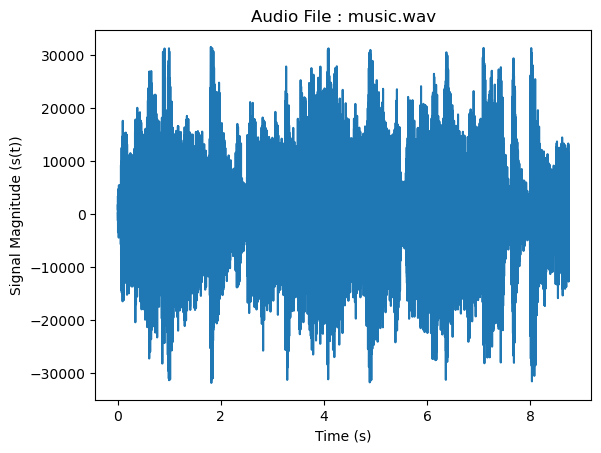

In [452]:
timeX = np.arange(0, sampleLen, 1/sampleFreq)

plt.plot(timeX, music)
plt.xlabel("Time (s)")
plt.ylabel("Signal Magnitude (s(t))")
plt.title(f"Audio File : {MUSIC_FILENAME}")

plt.show()

In [453]:
Audio(music, rate=sampleFreq)

## Generate noisy signal


In [454]:
snrdB = 10 #SNR in dB
snrLinear = 10**(snrdB / 10)

In [455]:
musicPower = np.mean(music**2)
noisePower = musicPower / snrLinear

In [456]:
noise = np.sqrt(noisePower) * np.random.normal(size=music.shape)

In [457]:
noisySignal = music + noise

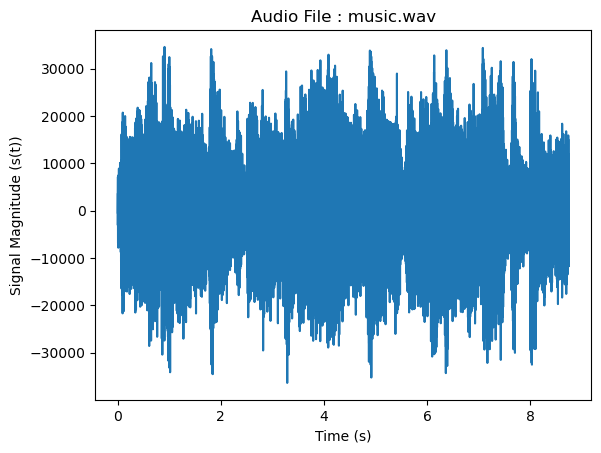

In [458]:
timeX = np.arange(0, sampleLen, 1/sampleFreq)

plt.plot(timeX, noisySignal)
plt.xlabel("Time (s)")
plt.ylabel("Signal Magnitude (s(t))")
plt.title(f"Audio File : {MUSIC_FILENAME}")

plt.show()

In [459]:
Audio(noisySignal, rate=sampleFreq)

## Calculating the STFT of the noisy signal


In [460]:
f, t, Zxx = stft(noisySignal, fs=sampleFreq, nperseg=1024)
magnitude = np.abs(Zxx)
phase = np.angle(Zxx)

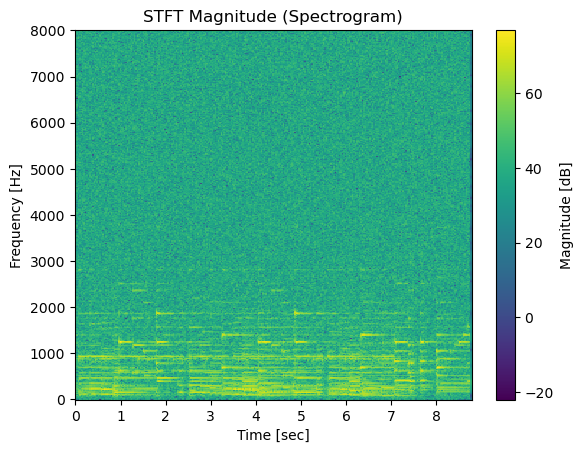

In [461]:
## Display the STFT

plt.pcolormesh(t, f, 20 * np.log10(np.abs(Zxx)))
plt.title('STFT Magnitude (Spectrogram)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Magnitude [dB]')
plt.show()

## Hard Thresholding


In [462]:
## Apply Hard thresholding 

threshold = 0.1*np.max(magnitude) #Threshold value

ZxxThresholding = magnitude * (magnitude >= threshold)

In [463]:
timeX, denoisedSignalHardThresholding = istft(ZxxThresholding * np.exp(1j * phase), fs=sampleFreq, nperseg=1024)

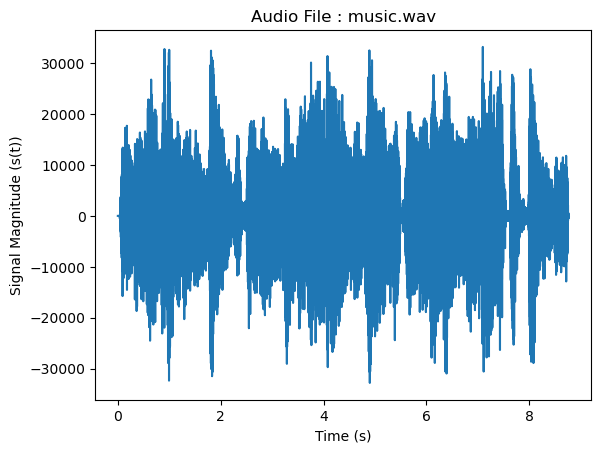

In [464]:
## Display denoised signal

plt.plot(timeX, denoisedSignalHardThresholding)
plt.xlabel("Time (s)")
plt.ylabel("Signal Magnitude (s(t))")
plt.title(f"Audio File : {MUSIC_FILENAME}")

plt.show()

In [465]:
Audio(denoisedSignalHardThresholding, rate=sampleFreq)

## Spectral Substraction


In [466]:
## Apply Spectral substraction

lambdaParameter = 1

_, _, ZxxNoise = stft(noise, fs=sampleFreq, nperseg=1024)
noiseMagnitude = np.abs(ZxxNoise)


ZxxSubstraction = np.maximum(magnitude - lambdaParameter * noiseMagnitude, 0)


In [467]:
timeX, denoisedSignalSubstraction = istft(ZxxSubstraction * np.exp(1j * phase), fs=sampleFreq, nperseg=1024)

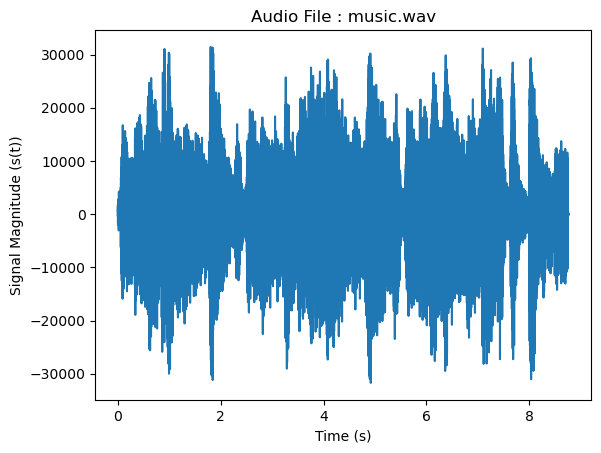

In [468]:
## Display denoised signal

plt.plot(timeX, denoisedSignalSubstraction)
plt.xlabel("Time (s)")
plt.ylabel("Signal Magnitude (s(t))")
plt.title(f"Audio File : {MUSIC_FILENAME}")

plt.show()

In [469]:
Audio(denoisedSignalSubstraction, rate=sampleFreq)

### Discussion


On retrouve ici les paramètres SNR vus précédemment, qui régissent la complexité de la tâche de débruitage.

Lors du débruitage par seuillage, le paramètre de seuil (ici exprimé comme pourcentage de la magnitude du signal), permet de définir la partie des fréquences supprimés du signal. En ce sens, s'il est trop important, l'opération de débruitage + reconstruction risque de supprimer certains aspects du signal originel, créant des artéfacts aufibles. Dans le cas du signal audio, une facteur de seuil de 10% semble adapté.

Le paramètre lambda dans le cas de la soustraction spectrale joue également un rôle similaire : trop faible et le bruit reste présent, trop élevé et cela occure des distorsions dans le signal. Dans notre cas, connaissant de manière exact le bruit ajouté au signal, un paramètre lambda égal à 1 permet une soustraction exacte, permettant de retrouver le signal d'entrée de manière parfaite. Dans le cas pratique, il serait nécessaire d'estimer la magnitude su bruit, par exemple lors d'un moment de silence.
